In [101]:
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import sys

### Q1

In [270]:
def simulate_single_server(T, lmda, service_distribution_option, service_discipline_option): 
    '''
    Simulating M/G/1/infinity/(FIFO or PS) queue
    Args:
        T (float): total time that the system is alive (closing time of the system assuming start time = 0)
        lmda (float): rate of arrival into the system
        service_distribution_option (int): choice of the service time distribution; should be one of {1, 2, 3};
            (1-> Erlang-2,2; 2-> Exp-1; 3-> Hyperexp-(0.1,1/9),(0.9,9))
        service_discipline_option (int, {1, 2}): choice of service discipline; should be from {1, 2}; (1: FIFO, 2: PS)
    Returns:
        2 lists, one containing the arrival times and the other containing departure times (list[float], list[float])
    '''
    if(service_distribution_option not in {1, 2, 3}):
        raise Exception("Only the service distributions mentioned in the question supported as of now!")
    if(service_discipline_option not in {1, 2}):
        raise Exception("Service discipline option can only be 1 or 2!")
    
    def simulate_arrival(lmda):
        '''
        Simulate poisson arrival @lmda
        '''
        u = np.random.rand()
        return 1/lmda*math.log(1/u)
    
    def generate_job_size(option):
        '''
        Generate service time for a job using the given option for its distribution
        '''
        if(option == 1): # erlang-2,2 => sum of 2 iid exponentials of rate 2
            u1 = np.random.rand()
            u2 = np.random.rand()
            lmda = 2
            return 1/lmda*math.log(1/u1) + 1/lmda*math.log(1/u2)
        elif(option == 2): # exponential
            lmda = 1
            u = np.random.rand()
            return 1/lmda*math.log(1/u)
        else: # hyperexponential
            u1 = np.random.rand()
            if(u1<0.1): # with probability 0.1, exponential(1/9)
                lmda = 1/9
            else:
                lmda = 9 # with probability 0.9, exponential(9)
            u2 = np.random.rand()
            return 1/lmda*math.log(1/u2)
        
    def sort(s, v):
        '''
        puts s into the sorted vector v in a sorted format
        '''
        l = len(v)
        i = 0
        while(i<l and v[i]<s):
                i += 1
        # first i where v[i]>=s
        return v[:i] + [s] + v[i:]

    # Initializing state variables
    Na = 0
    Nd = 0
    n = 0
    t = 0
    td = sys.maxsize
    A = []
    D = []
    S = []

    # Initializing time variables
    delta = simulate_arrival(lmda)
    ta = t+delta

    while(True):
        te = min(ta, td, T)
        if(te == ta):
            if(service_discipline_option == 2): # PS
                if(n > 0):
                    i = 0
                    while(i < n):
                        S[i] -= (ta-t)/n
                        i += 1
            # Updating for the arrival
            t = te
            Na += 1
            A.append(t) # A(Na) = t # A should be a vector
            n += 1
            # Deciding (or setting the time of departure)
            if(service_discipline_option == 1): # FIFO
                if(n == 1):
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
            else: # PS
                X = generate_job_size(service_distribution_option) # job size
                S = sort(X, S)
                assert(len(S) == n)
                td = t + n*S[0]
            # Next arrival
            delta = simulate_arrival(lmda) 
            ta = t + delta
        elif(te == td):
            if(service_discipline_option == 2): # PS
                R = S[0]
                i = 0
                while(i < n-1):
                    S[i] = S[i+1] - R
                    i += 1
                S = S[:n-1]
            # Accounting for the departure
            t = te
            n -= 1
            Nd += 1
            D.append(t) # D(Nd) = t # so should be D
            # Deciding time for the next departure
            if(n == 0):
                td = sys.maxsize
            else:
                if(service_discipline_option == 1): # FIFO
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
                else: # PS
                    assert(len(S) == n)
                    td = t + n*S[0]
        else:
            # stop as soon as T is reached
            return A, D

In [271]:
def populate_time_vector(event_time, k):
    '''
    Given an event time vector storing the time instances at which events occured, create (or populate) a time indexed vector tracking the number of events happened till each time index
    Args:
        event_time (list[float]): list of event times
        k (int): length of the time indexed vector that needs to be created
    Returns:
        an event time vector (list[int])
    '''
    time_vector = np.zeros(k)
    # populate time vector using event_time vector
    ne = 0
    i = 0
    j = 0
    while(i<k):
        while(i<k and i*0.2<event_time[j]):
            time_vector[i] = ne
            i += 1
        # Suppose 2 events in close context => will be taken care of in the next iteration
        if(i*0.2 >= event_time[j]):
            # an event at event_time[j] that needs to be reflected in the times henceforth
            ne += 1
            # For the next event, move to next event_time[j]
            j += 1
        if(j == len(event_time)):
            while(i<k):
                time_vector[i] = ne
                i += 1
    return time_vector

In [272]:
T = 600
k = 5*T
Tvec = [i*0.2 for i in range(5*T)]
lmda = 0.9

service_distribution_option_mapping = {1: "Erlang-2,2", 2: "Exp-1", 3: "Hyperexp-(0.1,1/9);(0.9,9)"}
service_discipline_option_mapping = {1: "FIFO", 2: "PS"}

num_iters = 200

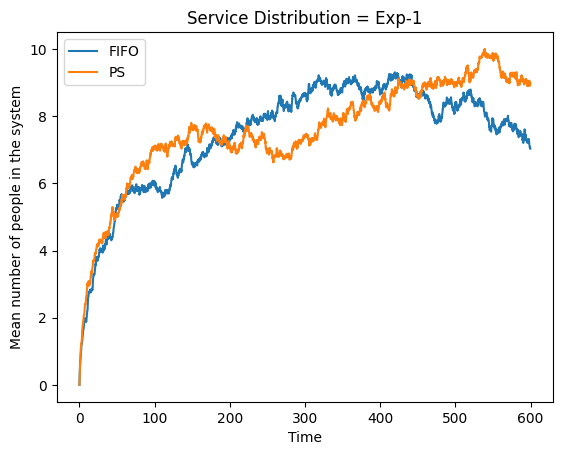

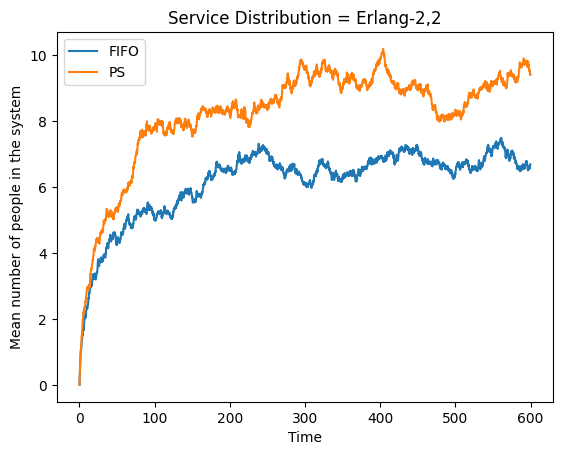

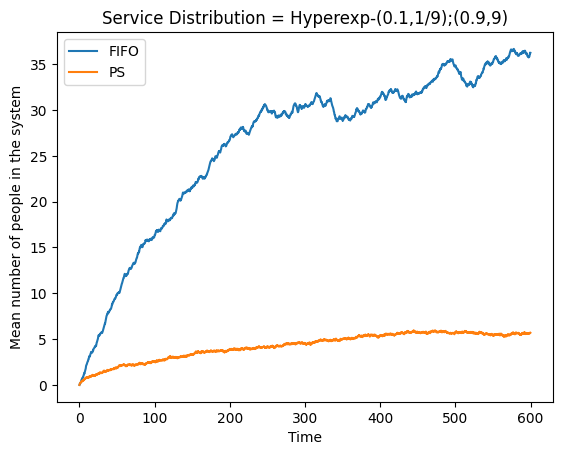

In [273]:
for service_distribution_option in [2, 1, 3]:
    for service_discipline_option in service_discipline_option_mapping.keys():
        num_people = np.zeros(k)
        for _ in range(num_iters):
            A, D = simulate_single_server(T, lmda, service_distribution_option, service_discipline_option)
            NA = populate_time_vector(A, k)
            ND = populate_time_vector(D, k)
            num_people += NA - ND
        num_people /= num_iters
        plt.plot(Tvec, num_people, label = service_discipline_option_mapping[service_discipline_option])
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Mean number of people in the system")
    plt.title(f"Service Distribution = {service_distribution_option_mapping[service_distribution_option]}")
    plt.show()

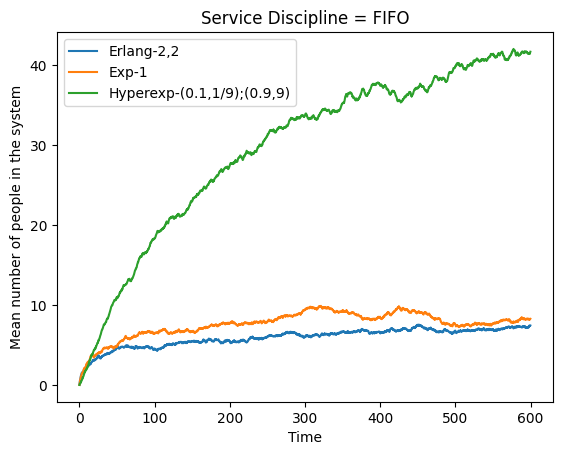

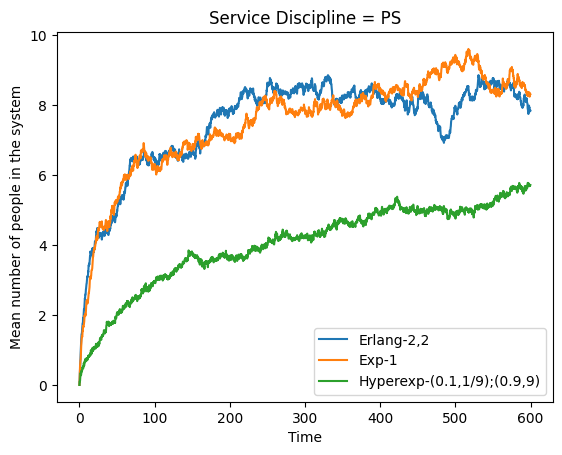

In [212]:
for service_discipline_option in service_discipline_option_mapping.keys():
    for service_distribution_option in service_distribution_option_mapping.keys():
        num_people = np.zeros(k)
        for _ in range(num_iters):
            A, D = simulate_single_server(T, lmda, service_distribution_option, service_discipline_option)
            NA = populate_time_vector(A, k)
            ND = populate_time_vector(D, k)
            num_people += NA - ND
        num_people /= num_iters
        plt.plot(Tvec, num_people, label = service_distribution_option_mapping[service_distribution_option])
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Mean number of people in the system")
    plt.title(f"Service Discipline = {service_discipline_option_mapping[service_discipline_option]}")
    plt.show()

### Q3

#### (b)

In [264]:
def generate_geometric(p):
    '''
    Simulate a geometric random variable (using just 1 uniform random variable)
    Args:
        p (float): the probability of success (as defined in the class); 0<=p<1
    Returns: 
        the number of wins until we get our first loss (int)
    '''
    u = np.random.rand()
    return math.floor(math.log(1/u)/math.log(1/p))

# Can this (the one below) be made more efficient? By inverting p and 1-p? 
# No need since we just use 1 (the minimum # of) uniforms to generate a geometric RV
def generate_Xn(p, n):
    '''
    Simulate a negative binomial random variable 
    Args:
        p (float): the probability of success (as defined in the class); 0<=p<1
        n (int): the number of losses until we keep sampling for wins
    Returns:
        the number of wins until we get n losses (int)
    '''
    ans = 0
    i = 0
    while(i<n):
        ans += generate_geometric(p)
        # a failure increased
        i += 1
    return ans

In [265]:
p = 0.3
nvec = [2, 4, 8, 16, 32]
ln = len(nvec)

In [261]:
# Run 1
# num_iters? Not needed since there is no Expectation over Xn; it is just directly put as Xn
output = np.zeros((ln, 3))
for i in range(ln):
    n = nvec[i]
    Xn = generate_Xn(p, n)
    output[i][0] = n
    output[i][1] = n/(n+Xn)
    output[i][2] = (n-1)/(n-1+Xn)

output = pd.DataFrame(output, index = nvec, columns = ["n", "n/(n+Xn)", "(n-1)/(n-1+Xn)"])
print(output)

       n  n/(n+Xn)  (n-1)/(n-1+Xn)
2    2.0  0.666667        0.500000
4    4.0  0.571429        0.500000
8    8.0  0.666667        0.636364
16  16.0  0.695652        0.681818
32  32.0  0.711111        0.704545


In [262]:
# Run 2
output = np.zeros((ln, 3))
for i in range(ln):
    n = nvec[i]
    Xn = generate_Xn(p, n)
    output[i][0] = n
    output[i][1] = n/(n+Xn)
    output[i][2] = (n-1)/(n-1+Xn)

output = pd.DataFrame(output, index = nvec, columns = ["n", "n/(n+Xn)", "(n-1)/(n-1+Xn)"])
print(output)

       n  n/(n+Xn)  (n-1)/(n-1+Xn)
2    2.0  0.666667        0.500000
4    4.0  0.666667        0.600000
8    8.0  0.888889        0.875000
16  16.0  0.695652        0.681818
32  32.0  0.727273        0.720930


In [269]:
# Run 3
output = np.zeros((ln, 3))
for i in range(ln):
    n = nvec[i]
    Xn = generate_Xn(p, n)
    output[i][0] = n
    output[i][1] = n/(n+Xn)
    output[i][2] = (n-1)/(n-1+Xn)

output = pd.DataFrame(output, index = nvec, columns = ["n", "n/(n+Xn)", "(n-1)/(n-1+Xn)"])
print(output)

       n  n/(n+Xn)  (n-1)/(n-1+Xn)
2    2.0  1.000000        1.000000
4    4.0  0.800000        0.750000
8    8.0  0.727273        0.700000
16  16.0  0.727273        0.714286
32  32.0  0.695652        0.688889


### Q4

In [189]:
def generate_gaussian(mu, sigma):
    '''
    Generate 2 independent realizations of a normally distributed random variable using box muller method
    Args:
        mu (float): mean (loc) of the random variables
        sigma (float): standard deviation (scale) of the random variables; should be > 0
    Returns:
        2 realizations of the random variable with the required distribution (float, float)
    '''
    while(True):
        u1 = np.random.rand()
        v1 = 2*u1 - 1
        u2 = np.random.rand()
        v2 = 2*u2 - 1
        s = v1**2 + v2**2
        if(s<=1):
            break
    x = math.sqrt(-2*math.log(s)/s)*v1
    x = x*sigma + mu
    y = math.sqrt(-2*math.log(s)/s)*v2
    y = y*sigma + mu
    return x, y

In [190]:
def get_option_value(S0, K, r, mu, sigma, T, type_of_option, num_iters = 10, delta_t = 1e-5):
    '''
    Compute (using simulation) the option value
    Args:
        S0 (float): present stock price
        K (float): strike price
        r (float): riskfree interest rate
        mu (float): guaranteed yield
        sigma (float): volatility of the stock (the underlying)
        T (float): Time to maturity
        type_of_option (int): the type of option for which to find value; should be one of {1, 2, 3};
        (European -> 1, Asian -> 2, Lookback -> 3; value will differ due to difference in their payoffs)
        num_iters (int, default = 10): number of iterations to run (to compute expected value)
        delta_t (float, default = 1e-5): the step size used while simulating brownian motion paths
    Returns:
        the value of the option (float)
    '''
    if (type_of_option not in [1, 2, 3]):
        raise Exception("type_of_option can only take a value from the set {1, 2, 3}!")
    
    num_steps = int(T/delta_t)
    value = 0
    for iter in range(num_iters):
        # generate final price
        price = S0
        price_term = 0
        for step in range(num_steps):
            if(step%2 == 0):
                w0, w1 = generate_gaussian(0, math.sqrt(delta_t))
            if(step%2 == 0):
                price = price*math.exp(sigma*w0 + (mu-sigma**2/2)*delta_t)
            else:
                price = price*math.exp(sigma*w1 + (mu-sigma**2/2)*delta_t)
            if(type_of_option == 2):
                price_term += price*delta_t/T
            elif(type_of_option == 3):
                price_term = max(price_term, price)
        if(type_of_option == 1):
            price_term = price
        # generate payoff
        payoff = max(price_term - K, 0)
        # Discounting payoff
        if(iter%2 == 0):
            val0, val1 = generate_gaussian(0, math.sqrt(T)) 
        if(iter%2 == 0):
            t1 = (r-mu)*val0/sigma
        else:
            t1 = (r-mu)*val1/sigma
        t2 = (r+(mu-r)**2/(2*sigma*sigma))*T
        value += payoff*math.exp(t1 - t2)
    # Taking expectation (or average)
    value = value/num_iters
    return value

In [251]:
def compute_option_value_using_black_scholes(S0, K, r, sigma, T):
    '''
    Compute option value using the closed form black scholes formula
    Args:
        S0 (float): present stock price
        K (float): strike price
        r (float): riskfree interest rate
        sigma (float): volatility of the stock (the underlying)
        T (float): Time to maturity
    Returns:
        the option value (float)
    '''
    # def N(x):
    #     return norm.cdf(x)
    def N(x): # P(X <= x): P(N(0, 1) <= x)
        num_rounds = 5000
        nmr = 0
        dnm = 0
        for _ in range(num_rounds):
            a, b = generate_gaussian(0, 1)
            if(a<=x):
                nmr += 1
            if(b<=x):
                nmr += 1
            dnm += 2
        return nmr/dnm
    
    d1 = (math.log(S0/K) + (r+sigma**2/2)*T)/(sigma*math.sqrt(T))
    d2 = (math.log(S0/K) + (r-sigma**2/2)*T)/(sigma*math.sqrt(T))
    return S0*N(d1) - K*math.exp(-r*T)*N(d2)

In [192]:
S0 = 59
K = 60
mu = 0.1
r = 0.05
sigma = 0.35
T_values = [0.1*i for i in range(1, 16)]
ltv = len(T_values)
option_name = {1: "European", 2: "Asian", 3: "Lookback"}

option_values = np.zeros([3, ltv])
for type_of_option in [1, 2, 3]:
    for j in range(ltv):
        T = T_values[j]
        option_values[type_of_option-1][j] = get_option_value(S0, K, r, mu, sigma, T, type_of_option, num_iters = 100, delta_t = 5e-5)
    
black_scholes_value = np.zeros(ltv)
for j in range(ltv):
    T = T_values[j]
    black_scholes_value[j] = compute_option_value_using_black_scholes(S0, K, r, sigma, T)

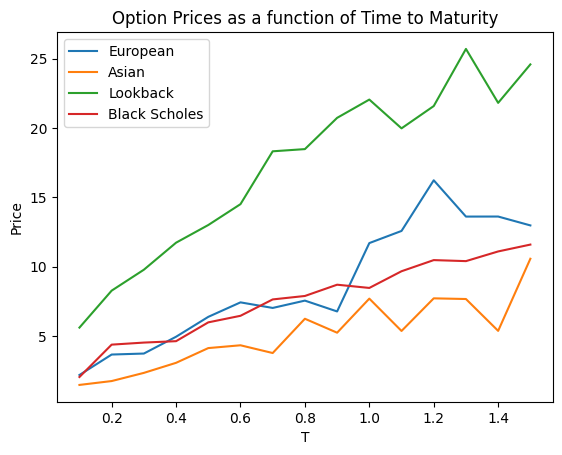

In [253]:
for type_of_option in [1, 2, 3]:
    plt.plot(T_values, option_values[type_of_option-1], label = option_name[type_of_option])

plt.plot(T_values, black_scholes_value, label = "Black Scholes")

plt.xlabel("T") # Time to maturity
plt.ylabel("Price")
plt.title("Option Prices as a function of Time to Maturity")
plt.legend()
plt.show()

### Q5

In [46]:
def simulate_markovian_queue(n0, lmda, mu, k):
    '''
    Simulating M/M/1/k queue
    Args:
        n0 (int): Initial load on the system (initial number of people in the queue); >= 0
        lmda (float): rate of arrival
        mu (float): rate of departure (or service, assuming departure happens immediately after the service)
        k (int): capacity of the buffer (or the queue)
    Returns:
        the earliest time when the system reaches its maximum buffer capacity or is empty (float)
    '''

    t = 0
    n = n0
    alpha = lmda + mu
    
    while(True):
        u = np.random.rand()
        v = np.random.rand()
        t += 1/alpha*math.log(1/u)
        if(alpha*v<lmda):
            # arrival
            n += 1
            if(n == k):
                # people in the system = 20
                return t
        else:
            # departure
            n -= 1
            if(n == 0): # 0 in the queue
                return t

In [147]:
k = 20
mu = 1

lmdavec = [0.4, 1, 2.5]
llmdavec = len(lmdavec)
n0vec = [0, 2, 6, 10, 14, 18, 20]
ln0vec = len(n0vec)
tmatrix = np.zeros([llmdavec, ln0vec])

num_iters = 100

output_df = np.zeros(((ln0vec-2)*llmdavec, 3))

for i in range(llmdavec):
    lmda = lmdavec[i]
    for j in range(1, ln0vec-1):
        n0 = n0vec[j]
        output = 0
        for _ in range(num_iters):
            output += simulate_markovian_queue(n0, lmda, mu, k)
        output /= num_iters
        output_df[i*5+(j-1)][0] = lmda
        output_df[i*5+(j-1)][1] = n0
        output_df[i*5+(j-1)][2] = output
        tmatrix[i][j] = output

output_df = pd.DataFrame(output_df, columns = ["lambda", "Initial load", "E(T)"])
print(output_df)

    lambda  Initial load       E(T)
0      0.4           2.0   3.141659
1      0.4           6.0  10.694185
2      0.4          10.0  16.868913
3      0.4          14.0  23.370215
4      0.4          18.0  26.181916
5      1.0           2.0  18.904805
6      1.0           6.0  47.396646
7      1.0          10.0  50.559018
8      1.0          14.0  41.502439
9      1.0          18.0  20.514757
10     2.5           2.0   9.594787
11     2.5           6.0   9.200953
12     2.5          10.0   6.676074
13     2.5          14.0   4.182634
14     2.5          18.0   1.273879


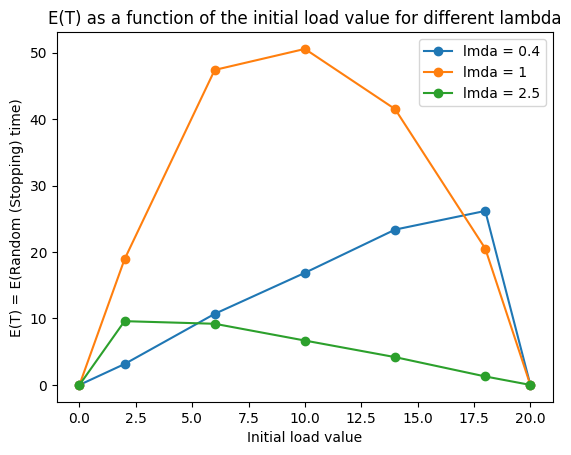

In [148]:
for i in range(llmdavec):
    plt.plot(n0vec, tmatrix[i, :], "-o", label = f"lmda = {lmdavec[i]}")

plt.xlabel("Initial load value")
plt.ylabel("E(T) = E(Random (Stopping) time)")
plt.legend()
plt.title("E(T) as a function of the initial load value for different lambda")
plt.show()